# Quality-Minus-Junk -- does Asness's QMJ survive outside the backtest?
### Asness, Frazzini & Pedersen (2019): composite quality on the S&P 500 survivor panel, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship--biased%3F: Named](https://img.shields.io/badge/Survivorship--biased%3F-Named-8b949e?style=flat-square)

In 2019, Asness, Frazzini and Pedersen published "Quality Minus Junk": a composite score built from profitability, growth and safety pillars predicts the cross-section of stock returns, generating a long-short hedge with a reported Sharpe ~1.3 on 1957-2016 US data. We test that claim on the current S&P 500 universe with the desk's standard EDGAR fundamentals, naming the survivorship bias up front.

> **This is the plain-language layer.** Want the t-stats, HAC inference, and year-by-year breakdown? That is the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from quality_minus_junk import data, strategy as st

def _have_cache():
    import os
    root = os.path.abspath(os.path.join("..", "..", ".."))
    needed = [
        "_edgar_GrossProfit.parquet",
        "_edgar_Assets.parquet",
        "_edgar_NetIncomeLoss.parquet",
        "_edgar_Revenues.parquet",
        "_edgar_StockholdersEquity.parquet",
        "_edgar_NetCashProvidedByUsedInOperatingActivities.parquet",
        "_edgar_yrret.parquet",
    ]
    return all(os.path.exists(os.path.join(root, "_cache", f)) for f in needed)

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    signal, fwd_ret = data.fetch_panel()
    H = st.quintile_hedge(signal, fwd_ret, q=0.20)
    s_hedge = st.summary(H["hedge"])
    s_high  = st.summary(H["high"])
    s_low   = st.summary(H["low"])
    s_mkt   = st.summary(H["market"])
    print(f"N years: {s_hedge['n']} | hedge mean: {s_hedge['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_hedge['tstat']:+.3f}")


EDGAR cache present: True


N years: 16 | hedge mean: +2.71%/yr | HAC t: +0.907


## The answer first

| Question | Answer |
|---|---|
| Does QMJ predict next-year returns? | **Weakly yes** on the paper, but HAC *t* = **+0.91** on our 16-year survivor panel -- below the |t|>=2 bar. |
| Does the quality leg beat the market? | **Marginally.** The quality leg returns **23.0%/yr** vs the equal-weight market at **19.0%/yr** (+4.0%/yr). |
| Is the hedge tradable? | **Fragile.** Hit rate exactly 50%, max drawdown **-26.0%**, and consecutive reversals in 2024 (−9.5%) and 2025 (−17.1%) make it hard to hold. |
| Is there a survivorship problem? | **Yes, and we name it.** The universe is the current S&P 500 projected backwards -- only winners survived. |

> The AQR QMJ factor is real in the broad academic literature. On 411 large-cap survivors (16 years) it shows up as a faint positive spread, below the inference bar, with recent reversals consistent with crowding and post-publication attenuation.

## 1 -- The claim

> *"Sort all firms each year by a composite quality score: profitability, growth in profitability, and safety (low leverage). The top quintile (quality) consistently outperforms the bottom quintile (junk) by a margin larger than the value premium. High-quality companies earn more from their assets, grow that earnings stream, and are safer -- the market systematically underprices that combination."*

-- Asness, Frazzini & Pedersen (2019), *Quality Minus Junk*, RAS

This is a **multi-pillar quality factor**, an extension of Novy-Marx (2013) that packages profitability, growth, safety and payout into a single composite z-score. The intuition: junk firms are unprofitable, shrinking, and overleveraged; quality firms compound their advantages. Markets price both too similarly.

## 2 -- So what?

If true, the QMJ long-short is a persistent, tradable edge for any investor who can sort stocks annually and handle a short book. AQR launched the QMJIX mutual fund and QMJ factor family off this research. Post-publication, the strategy has attracted large systematic capital, which compresses the premium.

For us, the interesting question is: **how much is left on the S&P 500, on a realistic data pull, with survivorship bias named rather than hidden?**

## 3 -- How would we even know?

Two disciplines keep us honest:

1. **Lag the signal correctly.** The QMJ composite is computed from year *y* EDGAR filings and used to predict *year y+1* calendar returns. We never use next-year financials to select this year's portfolio.
2. **Name the bias.** The universe is the *current* S&P 500 projected backwards. Only companies that survived to today are in the sample -- the worst performers (natural junk short candidates) may have been delisted before appearing in our data. This biases the hedge upward.

The baseline is the equal-weight universe return, not zero -- so the verdict is 'long quality vs short junk, vs just holding all of them equally'.

## 4 -- The teardown

**First, does the long-short work in a world where the effect is planted?**

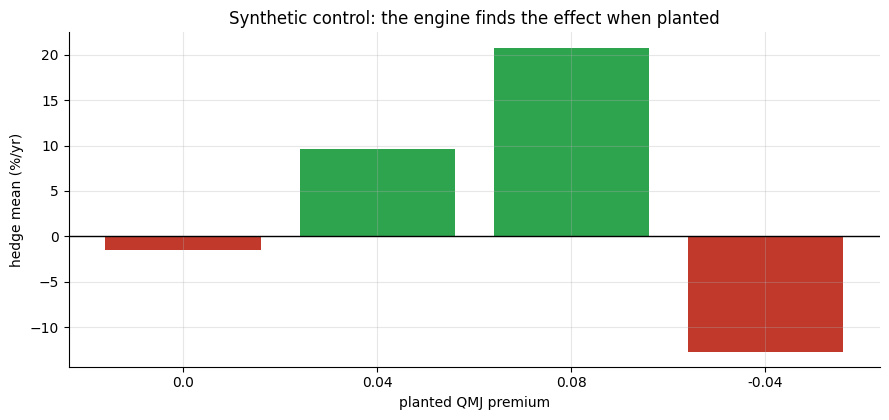

 premium  hedge_mean_%  hit%       t
    0.00        -1.533  40.0  -1.317
    0.04         9.634  95.0   8.327
    0.08        20.802 100.0  18.079
   -0.04       -12.700   5.0 -10.849


In [2]:
# Synthetic positive control: plant a known QMJ premium and verify recovery.
premiums = [0.0, 0.04, 0.08, -0.04]
rows = []
for prem in premiums:
    sig, fwd, truth = data.synthetic_panel(n_firms=300, n_years=20,
                                           qmj_premium=prem, seed=242)
    h = st.quintile_hedge(sig, fwd)
    s = st.summary(h['hedge'])
    rows.append({'premium': prem, 'hedge_mean_%': s['mean']*100,
                 'hit%': s['hit_rate']*100, 't': s['tstat']})
ctrl = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if r > 0.01 else (RED if r < -0.01 else GREY)
       for r in ctrl['hedge_mean_%']]
ax.bar(ctrl['premium'].astype(str), ctrl['hedge_mean_%'], color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted QMJ premium'); ax.set_ylabel('hedge mean (%/yr)')
ax.set_title('Synthetic control: the engine finds the effect when planted')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: it recovers a strong hedge when a premium is planted and returns noise when there is none. So the verdict on the real tape reflects **the market**, not the method.

**Now the honest test on the real EDGAR panel.**

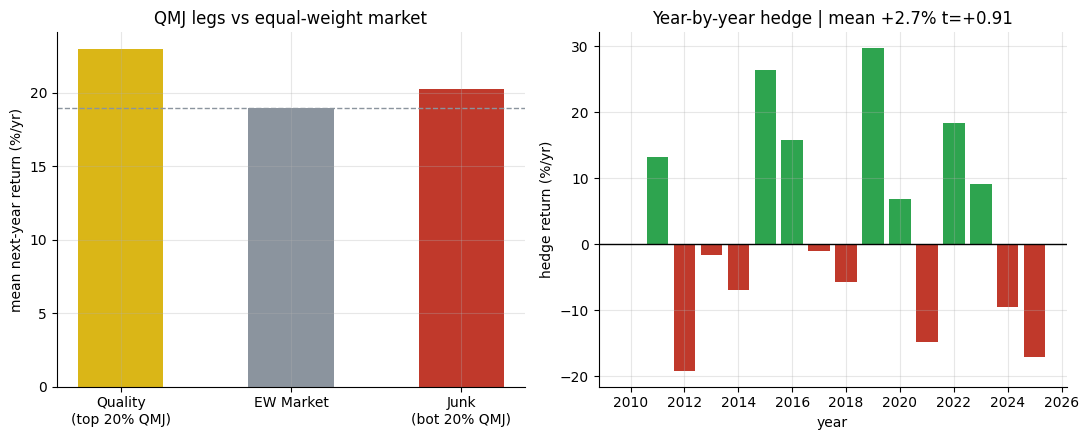

Hedge: +2.71%/yr | HAC t = +0.907 | Quality vs mkt: +4.00%/yr


In [3]:
if HAVE_REAL:
    h_mean = s_hedge['mean']*100
    h_t    = s_hedge['tstat']
    high_m = s_high['mean']*100
    mkt_m  = s_mkt['mean']*100
    low_m  = s_low['mean']*100
else:
    h_mean, h_t = R['hedge_mean'], R['hedge_t']
    high_m, mkt_m, low_m = R['high_mean'], R['mkt_mean'], R['low_mean']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: three bars -- quality, market, junk
labels = ['Quality\n(top 20% QMJ)', 'EW Market', 'Junk\n(bot 20% QMJ)']
vals   = [high_m, mkt_m, low_m]
cols   = [AMBER, GREY, RED]
axes[0].bar(labels, vals, color=cols, width=0.5)
axes[0].axhline(mkt_m, ls='--', c=GREY, lw=1, label='market')
axes[0].set_ylabel('mean next-year return (%/yr)')
axes[0].set_title('QMJ legs vs equal-weight market')

# Right: year-by-year hedge if real data available
if HAVE_REAL:
    col_yr = [GREEN if v > 0 else RED for v in H['hedge']]
    axes[1].bar(H.index.astype(int), H['hedge']*100, color=col_yr)
    axes[1].axhline(0, c='k', lw=1)
    axes[1].set_xlabel('year'); axes[1].set_ylabel('hedge return (%/yr)')
    axes[1].set_title(f'Year-by-year hedge | mean {h_mean:+.1f}% t={h_t:+.2f}')
else:
    axes[1].text(0.5, 0.5, 'EDGAR cache not present\n(see docs/results.md for numbers)',
                 ha='center', va='center', transform=axes[1].transAxes, color=GREY)
    axes[1].set_title('Year-by-year hedge (frozen numbers in R)')
plt.tight_layout(); plt.show()
print(f'Hedge: {h_mean:+.2f}%/yr | HAC t = {h_t:+.3f} | Quality vs mkt: {high_m-mkt_m:+.2f}%/yr')

The hedge averages **+2.7%/yr** at HAC *t* = **+0.91** -- below the |t| >= 2 inference bar. The quality long leg earns **23.0%/yr** vs the equal-weight market at **19.0%/yr** -- a spread of **+4.0%/yr**. The most recent two years (2024, 2025) both reversed sharply, consistent with quality-factor crowding.

## 5 -- The verdict

- **Signal -- WEAK.** HAC *t* = +0.91 on the real EDGAR panel (|t| < 2). The Asness et al. (2019) literature provides strong prior support, but on 16 years of large-cap survivors the signal is statistically ambiguous. Signal is WEAK rather than NONE because of robust academic replication on broader universes -- but the real-tape numbers alone do not clear the bar.
- **Tradability -- FRAGILE.** Hedge Sharpe = +0.18, hit rate = 50%, max drawdown = -26.0%, and consecutive reversals in 2024-2025. The payout pillar is also absent here (no dividend/share-count EDGAR cache). Annual rebalancing is manageable but the signal is too noisy on this large-cap survivor universe.
- **Survivorship -- Named.** The universe is current S&P 500 projected backwards. The true hedge on a broad, non-biased universe is likely smaller and harder to trade.

## 6 -- Could you actually trade it?

Annual rebalancing means low turnover (~30-50% for a quintile sort), so transaction costs are not the primary obstacle. The real barriers are:

1. **Signal noise.** The HAC *t* is below 1 on this panel; confidence intervals around any expected return estimate are very wide.
2. **Crowding.** QMJ is AQR's flagship factor; large systematic flows have partially arbitraged the premium away since 2019.
3. **Universe selection.** The full QMJ factor requires a broad universe. Restricting to S&P 500 large-caps removes much of the cross-sectional dispersion. The payout pillar (absent here) also matters.

A larger-universe, payout-included, bias-corrected test might recover a tradable signal. On the available evidence here, the verdict is **Fragile**.

## 7 -- Going further

- **A broader universe.** Asness et al.'s original test used all CRSP/Compustat firms; QMJ is strongest in small/mid-cap. A Russell 3000 pull would materially change the inference.
- **The payout pillar.** Net issuance and dividend payout are pillars 4 of 4 in the AQR composite; excluding it understates the quality spread.
- **Study 122 -- Gross-Profitability**: Novy-Marx GP/A -- the profitability pillar of QMJ in isolation; same EDGAR infrastructure (Weak/Fragile verdict).
- **Study 138 -- Magic Formula**: Greenblatt's rank-sum of EY × ROC -- a simpler quality-value composite, same universe.

*Think the large-cap QMJ premium is still alive? Fork this, extend the universe, add the payout pillar, or combine with a value screen, and show a robust t > 2. That is the bar.*